:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`custom_solvers.ipynb`**!

:::


# Creating custom solvers for use with NeMoS

To support flexibility and long-term maintenance, NeMoS now has a backend-agnostic solver interface, allowing the use of solvers from different backend libraries with different interfaces.
This also means that users can provide their own solvers, and as long as they adhere to the interface defined by `AbstractSolver`, they should be compatible with NeMoS and can be used for fitting models.

In the following we will walk through how one can create a NeMoS-compatible solver that uses [`scipy.optimize.minimize` with the modified Powell method](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-powell.html#optimize-minimize-powell), an algorithm not present in NeMoS by default.

## Define the `scipy` adapter

In order to adhere to the `AbstractSolver` interface, we have to define the following methods in our custom solver class:
- `__init__`: all solver parameters and settings should go here. The other methods only take the solver state, current or initial solution (model parameters), and the input data for the objective function.
- `init_state`: Initialize the solver state.
- `update`: Take one step of the optimization algorithm.
- `run`: Run a full optimization.
- `get_accepted_arguments`: Set of argument names that can be passed to `__init__`.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
import scipy.optimize
import numpy as np
from typing import NamedTuple
from nemos.solvers._abstract_solver import OptimizationInfo
from nemos.utils import get_flattener_unflattener


class ScipySolverState(NamedTuple):
    """State of a scipy-based solver."""

    # for keeping track of the number of steps when using update
    iter_num: int
    # res is for storing the results of the optimization run.
    res: dict
    # for notifying nemos if the optimization was succesful
    converged: bool


# NOTE: Omitting most types here for simplicity.
# For type hints of the interface, please see the `AbstractSolver` class.


class ScipySolver:
    """General adapter class for using scipy.minimize as a NeMoS solver."""

    def __init__(
        self,
        unregularized_loss,
        regularizer,
        regularizer_strength,
        has_aux,
        init_params,
        method: str,
        max_steps: int = 100,
        tol: float = 1e-8,
    ) -> None:
        """
        Required arguments to accept are `unregularized_loss`, `regularizer`, `regularizer_strength`.
        All parameters required for changing how the solver is created and run (except the input data) should come after these.
        These are the arguments we expose to the user and we will also need to list these in `get_accepted_arguments`.
        Users can set these when creating the model with e.g. `GLM(..., solver_kwargs={"max_steps" : 10})`.
        In our case these are stored and later passed to `scipy.optimize.minimize`:
        - `method`: name of the optimization method to use.
        - `max_steps`: maximum number of steps to take.
        - `tol`: tolerance for the convergence criteria.

        An alternative would be accept `**solver_kwargs`, store it, and pass anything in it to scipy.
        """
        # `regularizer.penalized_loss` returns a function which is the unregularized loss + a penalty term
        # we will pass this objective function to `scipy.optimize.minimize`
        self.fun = regularizer.penalized_loss(
            unregularized_loss, init_params, regularizer_strength
        )

        # storing these to later pass to scipy
        self.method = method
        self.tol = tol
        self.max_steps = max_steps

        assert not has_aux, "Not implementing aux support now."

    @classmethod
    def get_accepted_arguments(cls):
        """
        Explicitly list the arguments we accept.
        For alternative, more flexible implementations see the solvers
        implemented in `nemos.solvers`.
        """
        return {"method", "max_steps", "tol"}

    def init_state(self, init_params, *args):
        """
        We create a ScipySolverState where:
          - `iter_num` is 0 as we haven't taken any steps yet.
          - `res` an empty dictionary as we don't have any results yet.

        Has to accept `init_params` and `*args` even if it doesn't use them.
        """
        return ScipySolverState(0, {}, False)

    def run(self, init_params, *args):
        """
        Run a whole optimization by calling the helper function `_run_for_n_steps`
        defined below with the maximum number of steps allowed.

        Returns a tuple of the final parameters and the final solver state.
        """
        unstacked_final_params, res = self._run_for_n_steps(
            init_params, self.max_steps, *args
        )
        # unpack res, which has a custom type defined in scipy into a regular dict
        return (
            unstacked_final_params,
            ScipySolverState(res.nit, {**res}, res.success),
            None,
        )

    def update(self, params, state, *args):
        """
        While scipy doesn't expose individual steps, we hack our way around that
        by passing `options = {"maxiter" : 1}` to `scipy.optimize.minimize`
        and increment the number steps in the state by hand.
        """
        unstacked_final_params, res = self._run_for_n_steps(params, 1, *args)
        assert res.nit <= 1
        return (
            unstacked_final_params,
            ScipySolverState(state.iter_num + res.nit, {**res}, False),
            None,
        )

    def _run_for_n_steps(self, params, n_steps: int, *args):
        """
        Helper function so that we're not duplicating almost the same code in `run` and `update`.

        Prepare things in the form `scipy.optimize.minimize` expects them, then call it to
        run the optimization for `n_steps` steps.
        """
        # `params` returned by GLM is a tuple of (weight_matrix, intercept),
        # but `scipy.optimize.minimize` only accepts a 1D vector of parameters,
        # so flatten all parameters and concatenate them

        flattener_fun, unflattener_fun = get_flattener_unflattener(params)
        _flat_params = flattener_fun(params)

        # create an objective function that translates from the flat parameters accepted by scipy
        # back to their original form accepted by nemos.glm.GLM's objective function
        # so that it can be evaluated
        def _flat_obj(flat_params, *args):
            params_in_their_orig_shape = unflattener_fun(flat_params)
            return self.fun(params_in_their_orig_shape, *args)

        # pass the flat parameters and the objective function taking them
        # also the custom parameters we saved in __init__
        res = scipy.optimize.minimize(
            fun=_flat_obj,
            x0=_flat_params,
            args=args,
            method=self.method,
            options={"maxiter": n_steps},
            tol=self.tol,
        )

        return unflattener_fun(res.x), res


class ScipyPowell(ScipySolver):
    """Solver using the modified Powell algorithm."""

    def __init__(
        self,
        unregularized_loss,
        regularizer,
        regularizer_strength,
        has_aux,
        init_params,
        max_steps: int = 100,
        tol: float = 1e-8,
    ):
        return super().__init__(
            unregularized_loss,
            regularizer,
            regularizer_strength,
            has_aux,
            init_params,
            "Powell",
            max_steps,
            tol,
        )

### Checking that `ScipyPowell` is compatible with NeMoS

`SolverProtocol` defines the same interface as `AbstractSolver` and can be used to check the existence of all required methods:

In [3]:
import nemos as nmo

issubclass(ScipyPowell, nmo.solvers.SolverProtocol)

True

Now let's validate in more detail, checking that all methods have the expected signature and that the solver can be used on a small ridge regression problem.

In [4]:
# validate signature and test on small ridge problem not requiring aux support
nmo.solvers.validate_solver_class(ScipyPowell, test_ridge=True, loss_has_aux=False)

## Using `ScipyPowell` for model fitting

### Generate toy data

In [5]:
import numpy as np
from sklearn.datasets import make_regression

# num_samples, num_features, num_outputs = 100, 10, 3
num_samples, num_features, num_outputs = 100, 10, 1

# Generate a design matrix
X, y = make_regression(
    n_features=num_features,
    n_samples=num_samples,
    noise=10.0,
    n_targets=num_outputs,
)
# make spike counts
y = np.exp(y / y.max(axis=0) * 2 + 1)
y = np.random.poisson(y)
y = y.astype(np.float64)

# for multiple neurons, use PopulationGLM
if num_outputs > 1:
    glm_class = nmo.glm.PopulationGLM
else:
    glm_class = nmo.glm.GLM

### Register `ScipyPowell` in NeMoS's solver registry

Registering lets NeMoS know that we have a custom implementation of the Powell algorithm using scipy as its backend.

In [6]:
nmo.solvers.register("Powell", ScipyPowell, backend="scipy")

The `backend` argument is only a string and can be anything, it's used for choosing between multiple implementations of the same algorithm.

Additional arguments of `nmo.solvers.register` are:
- `replace`: If an implementation for the given algorithm and backend names is already present in the registry, overwrite it.
<br>
Setting this to `True` can be handy when developing a solver, as changes require re-registration to take effect.
- `default`: Set this implementation as the default for the algorithm. Can also be done with `nmo.solvers.set_default_backend`.
<br>
Setting this to `True` would tell NeMoS that we want to use this as the default Powell implementation.
- `validate`: Validate all required methods exist and have correct signatures. True by default.
- `test_ridge_without_aux` : Validate solver signatures and functionality by running a small ridge regression, objective function without aux.
- `test_ridge_with_aux`: same as before, also testing that objective functions with auxiliary variables are handled.

### Create the model and fit

Passing `"Powell"` as the solver_name to `GLM`, it will now look up this class in the solver registry, and `model.fit` will call `ScipyPowell.run`.

If we have multiple implementations of a given algorithm (for example because we created and registered `ScipyLBFGS` instead), specifying only the algorithm's name will use the implementation set as the default for the given algorithm.
<br>
In case we want to use a non-default implementation, we have to specify its backend, such as `LBFGS[scipy]`.

To the default backend for an algorithm, use `nemos.solvers.set_default_backend`.

#### Declaring compatibility with regularizers

Trying to use our solver would fail because NeMoS checks if the solver's algorithm is compatible with the regularizer we are using.
<br>
So before using our solver for model fitting, we have to declare that it is compatible with the regularizer we want to use it with:

In [7]:
nmo.regularizer.UnRegularized.allow_solver("Powell")

Now model fitting works the same as with built-in solvers:

In [8]:
model = glm_class(solver_name="Powell")
model.fit(X, y)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f5c54aa6700>
,regularizer,UnRegularized()
,fix_params,"(None, ...)"
,solver_name,'Powell'
,solver_kwargs,{}
,regularizer_strength,None
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](10,)",Array([ 0.460...dtype=float64)


Finally, we can inspect the model to show that it is using `ScipyPowell`:

In [9]:
# the solver string or class
print(model.solver_name)
# the actual solver instance that is created from the string or class
print(model._solver)
# GLM.optimizer_run (called within GLM.fit) corresponds to this instance's .run method
print(model.optimizer_run)

Powell
<bound method ScipySolver.run of <__main__.ScipyPowell object at 0x7f5c20137650>>


### Test the update method

`model.fit` called `ScipyPowell.run` to perform a whole optimization and return the final solution.

Repeatedly calling a `model.update` calls `ScipyPowell.update` to perform a single step of the optimization. While this is usually much slower, this way we can follow the evolution of the loss function's value or the model parameters:

[Text(0.5, 0, 'Iteration'), Text(0, 0.5, 'Obj. fun. value')]

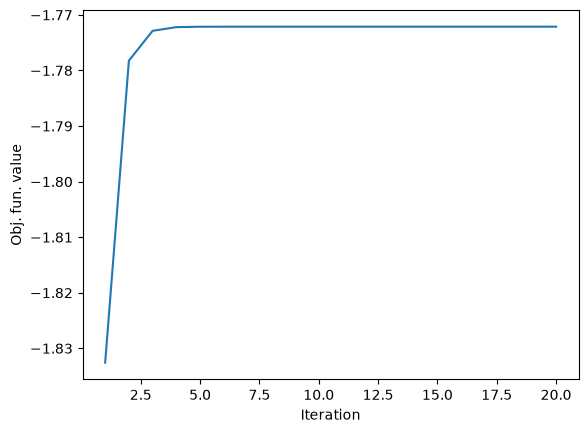

In [10]:
import matplotlib.pyplot as plt

params = model.initialize_params(X, y)
state = model.initialize_optimizer_and_state(params, X, y)

fig, ax = plt.subplots()
scores = []
for i in range(20):
    params, state = model.update(params, state, X, y)
    scores.append(model.score(X, y))
ax.plot(range(1, 21), scores)
ax.set(xlabel="Iteration", ylabel="Obj. fun. value")

## Saving and loading models with custom solvers

### Registered algorithms

In [11]:
save_path = "glm_with_custom_solver.npz"
model.save_params(save_path)

Because the solver is registered and is allowed by the model's regularizer, loading the solver just works:

In [12]:
loaded_model = nmo.load_model(save_path)
loaded_model._solver_spec

"Powell[scipy]" - SolverSpec(
    algo_name="Powell",
    backend="scipy",
    implementation=__main__.ScipyPowell
)

### Using a new algorithm

Now imagine that your fitting script finished and saved your model, now you would like to load it in a Jupyter notebook to do some analysis.

Just like before using it to fit a model, in order for a GLM object with a custom solver to be loaded, the solver has to be registered and the algorithm it implements must be compatible with the regularizer.

We will simulate this scenario by reversing the registration we did above and "forget" any knowledge we had of the Powell algorithm.

In [13]:
# delete any knowledge of Powell, simulating a new kernel

nmo.solvers._solver_registry._registry.pop("Powell", None)
nmo.solvers._solver_registry._defaults.pop("Powell", None)

nmo.regularizer.UnRegularized._allowed_solvers = tuple(
    algo for algo in nmo.regularizer.UnRegularized._allowed_solvers if algo != "Powell"
)

Now trying to load the model would give an error because the solver is not registered and none of the regularizers know about and allow the Powell algorithm.

Loading a model with a custom solver requires:
- The class definition of the solver implementation.
- Registering the backend
- In case of algorithms not shipped in NeMoS (see `nemos.solvers.list_available_algorithms`), declaring that the implemented algorithm is compatible with the regularizer used.

In [14]:
# 1. define the class
# class ScipyPowell(ScipySolver):
#     ...

# 2. register the solver
nmo.solvers.register("Powell", ScipyPowell, "scipy")

# 3. Declare compatibility with the regularizer
nmo.regularizer.UnRegularized.allow_solver("Powell")

After these 2 lines NeMoS knows where to find the implementation and that it is an allowed solver when not using regularization:

In [15]:
nmo.load_model(save_path)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f5c54aa6700>
,regularizer,UnRegularized()
,fix_params,"(None, ...)"
,solver_name,'Powell'
,solver_kwargs,{}
,regularizer_strength,None
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ndarray[float64](10,)","[ 0.46, 0.29,-0.07,...,-0.06, 0.15, 0.17]"
